# ПОДХОД К РЕШЕНИЮ

Моё решение я разделил на несколько основных этапов: cначала я посмотрел на данные и увидел, что platform записан в разных форматах (iPhone отдельно от ios, desktop отдельно от web), поэтому сначала свёл всё к трём значениям: web, android, ios. Заодно убрал точные дубликаты строк в событиях.

Дальше нашёл проблему с временными диапазонами: часть событий в train происходит уже после конца окна наблюдения куки, а рядом почти всегда встречается captcha_shown, то есть это уже помеченные случаи. Если такие события не выкинуть, признаки будут смотреть в будущее и офлайн оценка окажется завышенной (то есть прямого вида лик данных), поэтому оставил только события строго внутри окна. Заодно восстановил пропуски в категории, локации и типе продавца по item_id, у одного объявления они всегда одинаковые!

После этого я перешёл к подробному изучению данных по восьми направлениям, которые выделил из подсказок внизу и своих идей: паузы между событиями, user-agent и платформа, разнообразие того, что кука смотрит, поиск, курсор, возраст куки, пересечения кук по общим объявлениям, сдвиг между train и test. И с этой информации поддвердил в полне реальные вещи, что у ботов короче паузы, курсор (там, где он вообще есть, это только треть кук на web) у ботов собран в плотное пятно вместо равномерного разброса у людей, боты смотрят больше локаций и категорий даже при одинаковой активности, а куки, которые в один день смотрели одно объявление с другими куками, чаще оказываются ботами. Отдельно проверил, что train и test похожи по агрегатам, что помогло сделать вывод, что валидации можно доверять.

На основе этих находок собрал 60 признаков по восьми группам, а после сделал отбор фичей, а именно проверил по очереди, что теряется при удалении каждой группы признаков, на пяти окнах валидации по времент. Паузы, курсор, объём, разнообразие и воронка оказались нужны, ua помогает в мобильном сегменте, поиск и признаки куки нейтральны. Также из созданных фичей, пробовал ещё сократить их по важности, но выигрыша это не дало, поэтому оставил все 60 (в реальном проекте надо было бы гораздо подробнее изучить этот вопрос, просто к сожалению не хватило времени(( )

А после этого разделил куки на три сегмента по доступным данным (web с курсором, web без курсора, мобильные) и попробовал свою идею, которая казалась мне максимально логичной, обучить отдельную модель под каждый сегмент, но лучше не стало, поэтому вернулся к одной модели на всех. После этого аеребрал побольше моделей абсолютно разных видов: линейные, RandomForest, ExtraTrees, kNN, SVM, MLP и четыре бустинга. Бустинги оказались стабильно впереди и примерно равны друг другу, значит дело было в признаках, а не в выборе модели. Взвешивание классов не помогло, так как метрика ранговая. В итоге построил ансамбль из трёх бустингов (CatBoost, XGBoost, LightGBM), усредняя их ранги, это дало небольшой, но стабильный прирост над любой моделью по отдельности. В реальности я понимаю, что ансамбль только из бустингов, звучит не очень, так как суть бустинга в разных моделях, но так как в моём случае это даёт улучшение, а если ещё покапаться в теории, то можно понять, что на самом деле все три бустинга работают по разному, особенно в постраение листьев, поэтому в качестве контеста, почему нет))

Отдельно попробовал ещё две идеи: модель на уровне отдельных событий и моделью устройства, но они обе не дали прироста..

# импорты

In [140]:
import time, warnings, random
from importlib.metadata import version, PackageNotFoundError
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

random_state = 42
random.seed(random_state); np.random.seed(random_state)

# Метрика из задаемя

In [141]:
"""
Официальная метрика кейса: Precision @ Recall >= 0.70.

Этот же файл использует проверяющая система. Считайте им метрику на своей валидации,
чтобы локальные числа совпадали с итоговыми.

Определение
-----------
Куки сортируются по `score` по убыванию. Перебираются все пороги; для каждого
отмечаются куки со `score >= threshold` и считаются precision и recall.
Результат — **максимальный precision среди порогов, у которых recall >= 0.70**.

Две детали, в которых легко ошибиться:

1. Одинаковые score обрабатываются **одной группой**. Нельзя разделить куки с равным
   score: либо отмечены все, либо никто. Порядок строк на результат не влияет.
2. Берётся именно максимум по допустимой области, а не первая точка, где полнота
   достигнута. Precision вдоль кривой не монотонен, и эти два числа различаются.
   Пример: ответы в порядке убывания score — 1, 0, 1, 1, 1. Первая точка с recall >= 0.7
   даёт precision 0.75, следующая — 0.80. Правильный ответ 0.80.
"""

from __future__ import annotations

import numpy as np

TARGET_RECALL = 0.70


def pr_curve(y_true, score) -> tuple[np.ndarray, np.ndarray]:
    """(precision, recall) в точках на границах групп одинакового score."""
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    if y_true.shape != score.shape:
        raise ValueError("y_true и score разной длины")

    n_pos = int(y_true.sum())
    if n_pos == 0:
        return np.array([]), np.array([])

    order = np.argsort(-score, kind="mergesort")
    y, s = y_true[order], score[order]

    tp = np.cumsum(y)
    k = np.arange(1, len(y) + 1)
    ends = np.r_[s[1:] != s[:-1], True]      # последняя строка каждой группы равных score
    return tp[ends] / k[ends], tp[ends] / n_pos


def precision_at_recall(y_true, score, recall: float = TARGET_RECALL) -> float:
    """Максимальный precision среди порогов с recall >= `recall`."""
    prec, rec = pr_curve(y_true, score)
    if len(prec) == 0:
        return float("nan")
    ok = rec >= recall
    return float(prec[ok].max()) if ok.any() else 0.0


def recall_at_fpr(y_true, score, fpr: float = 0.01) -> float:
    """Диагностика: какую долю ботов ловим, задев не более `fpr` доли людей.

    Как и основная метрика, работает по группам одинакового score.
    """
    y_true = np.asarray(y_true, dtype=int)
    score = np.asarray(score, dtype=float)
    n_pos, n_neg = int(y_true.sum()), int((1 - y_true).sum())
    if n_pos == 0 or n_neg == 0:
        return float("nan")

    order = np.argsort(-score, kind="mergesort")
    y, s = y_true[order], score[order]
    ends = np.r_[s[1:] != s[:-1], True]
    tp = np.cumsum(y)[ends]
    fp = np.cumsum(1 - y)[ends]

    allowed = fp <= fpr * n_neg
    return float(tp[allowed].max() / n_pos) if allowed.any() else 0.0


if __name__ == "__main__":
    # самопроверка на примерах из описания
    assert precision_at_recall([1, 0, 1, 1, 1], [5, 4, 3, 2, 1]) == 0.8
    assert precision_at_recall([1, 1, 0, 0], [0.5] * 4) == 0.5      # группа равных score
    assert precision_at_recall([0, 0, 1, 1], [0.5] * 4) == 0.5      # порядок не влияет
    assert recall_at_fpr(np.r_[np.ones(10), np.zeros(90)], np.full(100, 0.5)) == 0.0
    print("метрика: самопроверка пройдена")


метрика: самопроверка пройдена


# Просмотр данных

In [142]:
train = pd.read_csv('/kaggle/input/datasets/sashatx/data-avito-test/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('/kaggle/input/datasets/sashatx/data-avito-test/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('/kaggle/input/datasets/sashatx/data-avito-test/events.csv', parse_dates=['event_ts'])
cookies = pd.concat([train.assign(split='train'), test.assign(split='test')], ignore_index=True)

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [143]:
events.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


In [144]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328905 entries, 0 to 328904
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   cookie_id      328905 non-null  object        
 1   event_ts       328905 non-null  datetime64[ns]
 2   eid            328905 non-null  int64         
 3   event_name     328905 non-null  object        
 4   platform       328905 non-null  object        
 5   user_agent     328905 non-null  object        
 6   item_id        214308 non-null  float64       
 7   item_category  295985 non-null  object        
 8   item_location  305112 non-null  object        
 9   seller_type    195052 non-null  object        
 10  search_query   100402 non-null  object        
 11  search_page    100402 non-null  float64       
 12  pointer_x      108540 non-null  float64       
 13  pointer_y      108540 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(8

In [145]:
events['platform'].value_counts()

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

# Предобработка данных

In [146]:
print('окна train:', train.window_start_ts.min().date(), '-', train.window_start_ts.max().date())
print('окна test:', test.window_start_ts.min().date(),  '-', test.window_start_ts.max().date())
print('дубликатов событий:', events.duplicated().sum())
print('events отсортирован по времени:', events.event_ts.is_monotonic_increasing)

окна train: 2026-04-06 - 2026-04-19
окна test: 2026-04-20 - 2026-04-26
дубликатов событий: 4863
events отсортирован по времени: False


## убираем дубли и чистим нейминг

In [147]:
n0 = len(events)
events = events.drop_duplicates()
events['platform_clean'] = (events['platform'].str.lower().replace({'iphone': 'ios', 'desktop': 'web'}))
print('удалено дублей:', n0 - len(events))
print(events['platform_clean'].value_counts().to_dict())

удалено дублей: 4863
{'web': 182943, 'android': 124988, 'ios': 16111}


## чистка ликов времени

In [148]:
events = events.merge(cookies[['cookie_id', 'split', 'window_start_ts', 'window_end_ts']], on='cookie_id', how='inner')
is_inside_window = (events['event_ts'] >= events['window_start_ts']) & (events['event_ts'] < events['window_end_ts'])

print('\nдоля событий вне окна:')
print((~is_inside_window).groupby(events['split']).mean().round(3))
print('\nтипы событий вне окна:')
print(events.loc[~is_inside_window, 'event_name'].value_counts().head(3))
events = events[is_inside_window].copy()
print('\nсобытий после отсечения:', len(events))


доля событий вне окна:
split
test     0.000
train    0.171
dtype: float64

типы событий вне окна:
event_name
item_view              12542
search_results_view    10450
captcha_shown           7831
Name: count, dtype: int64

событий после отсечения: 283833


## восстановление пропусков для id товара

In [149]:
for column in ['item_category', 'item_location', 'seller_type']:
    events[column] = events[column].fillna(events.groupby('item_id')[column].transform('first'))
events = (events.sort_values(['cookie_id', 'event_ts', 'eid'], kind='stable').drop(columns=['platform', 'eid']).reset_index(drop=True))

# подробный EDA

## вспомогательные функции и колонки после очистки

In [150]:
HUMAN, BOT = '#1f77b4', '#d62728'
PAL, NAME = {0: HUMAN, 1: BOT}, {0: 'человек', 1: 'бот'}

def show():
    plt.tight_layout()
    plt.show()

def auc(target, score):
    ok = score.notna()
    a = roc_auc_score(target[ok], score[ok])
    return max(a, 1 - a)

def hist_by_class(ax, d, col, bins, title):
    for t in (0, 1):
        ax.hist(d.loc[d.target == t, col].dropna(), bins=bins, alpha=.6, color=PAL[t], label=NAME[t], density=True)
    ax.set_title(title); ax.legend()

y = train.set_index('cookie_id').target
events['target'] = events.cookie_id.map(y)
events['sec_from_start'] = (events.event_ts - events.window_start_ts).dt.total_seconds()
events['pause'] = events.groupby('cookie_id').sec_from_start.diff()
ua = events.user_agent.fillna('')
events['is_headless'] = ua.str.contains('Headless')
events['browser'] = np.select(
    [ua.str.contains('curl|Go-http|Scrapy|urllib|node-fetch|python-requests'), ua.str.contains('Headless'), ua.str.contains('YaBrowser'), ua.str.contains('Firefox'), ua.str.contains('Edg'), ua.str.contains('Chrome'), ua.str.contains('Safari'), ua.str.startswith('Avito/')],
    ['scraper_lib', 'headless', 'yandex', 'firefox', 'edge', 'chrome', 'safari', 'app'], default='other')
train_events = events[events.split == 'train'].copy()

assert events.duplicated().sum() == 0
assert (events.event_ts >= events.window_start_ts).all() and (events.event_ts < events.window_end_ts).all()
print('событий после очистки:', len(events), 'в train:', len(train_events))

событий после очистки: 283833 в train: 195484


## анализ моментов времени

           count   mean     std  min  10%   25%   50%    75%     90%     max
target                                                                      
0.0     159187.0  744.1  1904.8  0.0  8.0  20.0  47.0  120.0  3185.4  9760.0
1.0      25206.0  430.9  1489.7  0.0  5.0   7.0  14.0   35.0   404.0  9608.0
доля пауз <= 1c: {0.0: 0.017, 1.0: 0.005}
доля пауз <= 5c: {0.0: 0.063, 1.0: 0.15}
доля пауз <= 10c: {0.0: 0.127, 1.0: 0.396}
доля пауз <= 60c: {0.0: 0.579, 1.0: 0.831}


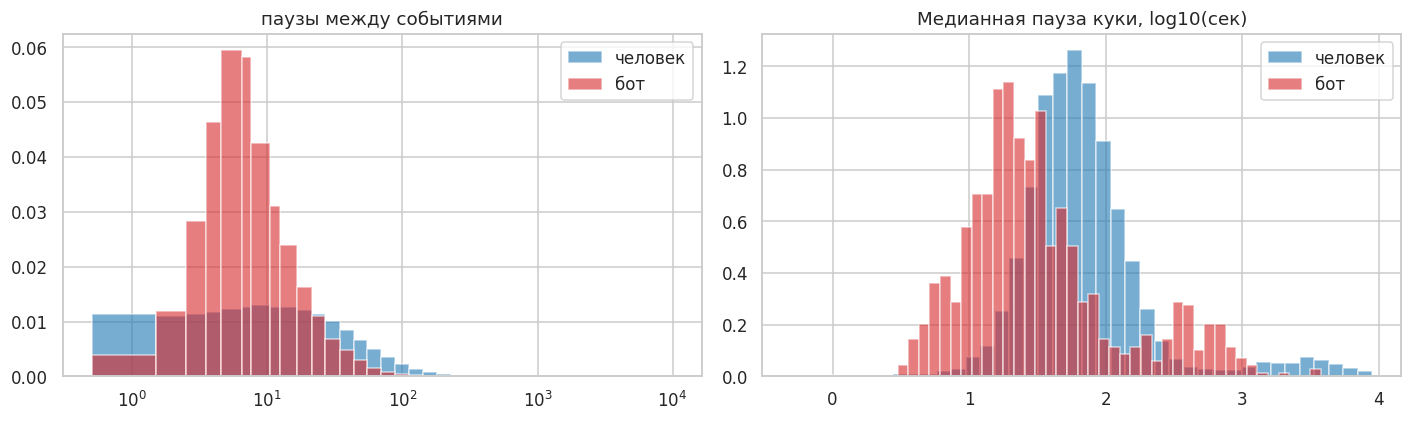

ROC-AUC медианной паузы: 0.727


In [151]:
pauses = train_events.dropna(subset=['pause'])
print(pauses.groupby('target').pause.describe(percentiles=[.1, .25, .5, .75, .9]).round(1))
for limit in [1, 5, 10, 60]:
    print(f'доля пауз <= {limit}c:', (pauses.pause <= limit).groupby(pauses.target).mean().round(3).to_dict())

cookie_pause = pauses.groupby('cookie_id').pause.median().rename('median_pause').to_frame().join(y)
cookie_pause['log10_median'] = np.log10(cookie_pause.median_pause.clip(lower=0.5))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
hist_by_class(ax[0], pauses[pauses.pause >= 1], 'pause', np.unique(np.round(np.logspace(0, 4, 40))) - 0.5, 'паузы между событиями')
ax[0].set_xscale('log')
hist_by_class(ax[1], cookie_pause, 'log10_median', 40, 'Медианная пауза куки, log10(сек)')
show()
print('ROC-AUC медианной паузы:', round(auc(cookie_pause.target, cookie_pause.median_pause), 3))

Видно, что медиана паузы у ботов заметно ниже (14 против 47 у людей),виден ровный, предсказуемый темп. ROC-AUC одной медианы паузы примерно 0.73, один из сильнейших одиночных признаков!

## user-agent и платформа

In [152]:
cookie_ua = train_events.groupby('cookie_id').user_agent.agg(lambda s: s.mode().iloc[0]).to_frame('ua').join(y)
ua = cookie_ua.ua
cookie_ua['kind'] = np.select([ua.str.startswith('Avito/') & ua.str.contains('Android'), ua.str.startswith('Avito/') & ua.str.contains('iPhone'), ua.str.contains('Android|iPhone'), ua.str.contains('Headless')], ['app_android', 'app_ios', 'mobile_web', 'headless'], default='desktop_web')
scraper = (train_events.browser == 'scraper_lib').groupby(train_events.cookie_id).any()

mobile_ua = train_events.user_agent.str.contains('Android/iPhone/iPad', na=False)
mobile_platform = train_events.platform_clean.isin(['android', 'ios'])
mismatch = (mobile_ua != mobile_platform).groupby(train_events.cookie_id).mean()
n_ua = train_events.groupby('cookie_id').user_agent.nunique()
anomaly = pd.DataFrame({'ua_mismatch': mismatch > 0, 'n_ua': n_ua.clip(upper=3)}).join(y)

app = cookie_ua[cookie_ua.kind == 'app_android'].copy()
app['app_version'] = app.ua.str.extract(r'Avito/(\d+)')[0]
app['device'] = app.ua.str.extract(r'; ([^)]+)\)')[0]

print(cookie_ua.groupby('kind').target.agg(['size', 'mean']).rename(columns={'size': 'кук', 'mean': 'доля ботов'}).round(3))
print('\nкуки со scraper-библиотекой в UA:', int(scraper.sum()), 'доля ботов среди них:', round(y[scraper[scraper].index].mean(), 3))
print('\nплатформа не совпадает с ua хотя бы в одном событии:'); print(anomaly.groupby('ua_mismatch').target.agg(['size', 'mean']).round(3))
print('число разных ua у куки:'); print(anomaly.groupby('n_ua').target.agg(['size', 'mean']).round(3))
print('\nAndroid-приложение, доля ботов:')
for col in ['app_version', 'device']:
    print(app.groupby(col).target.agg(['size', 'mean']).round(3).T.to_string())

              кук  доля ботов
kind                         
app_android  1754       0.103
app_ios       387       0.044
desktop_web  5631       0.091
headless      286       0.262
mobile_web   3033       0.038

куки со scraper-библиотекой в UA: 200 доля ботов среди них: 0.22

платформа не совпадает с ua хотя бы в одном событии:
             size   mean
ua_mismatch             
False        5917  0.099
True         5174  0.060
число разных ua у куки:
       size   mean
n_ua              
1     10295  0.082
2       107  0.009
3       689  0.073

Android-приложение, доля ботов:
app_version      118      120      122
size         521.000  576.000  657.000
mean           0.061    0.095    0.142
device  M2101K6G  SM-A125F  SM-A515F
size     594.000   592.000   568.000
mean       0.141     0.068     0.099


доля ботов в каждой группе и отдельно куки со скрейпер-библиотеками в UA (curl, Scrapy, python-requests) и несовпадение платформы с UA

## разнообразие того, что смотрит кука

In [153]:
by_cookie = train_events.groupby('cookie_id')
diversity = pd.DataFrame({'n_events': by_cookie.size(), 'n_items': by_cookie.item_id.nunique(), 'n_categories': by_cookie.item_category.nunique(),'n_locations': by_cookie.item_location.nunique(), 'n_queries': by_cookie.search_query.nunique()}).join(y)
diversity['events_per_category'] = diversity.n_events / diversity.n_categories.replace(0, np.nan)

print(diversity.groupby('target').median().round(2).T.rename(columns={0: 'человек', 1: 'бот'}))
diversity['activity'] = pd.cut(diversity.n_events, [0, 5, 10, 20, 40, 500])
print('\nчисло локаций при одинаковой активности (по числу событий):')
print(diversity.pivot_table(index='activity', columns='target', values='n_locations', observed=True).round(2))

target               человек   бот
n_events                12.0  20.0
n_items                  6.0  10.0
n_categories             2.0   2.0
n_locations              5.0   8.0
n_queries                3.0   4.0
events_per_category      5.5  11.0

число локаций при одинаковой активности (по числу событий):
target         0      1
activity               
(0, 5]      1.99   2.70
(5, 10]     3.66   4.78
(10, 20]    5.79   7.13
(20, 40]    9.56  11.31
(40, 500]  15.43  17.98


 Боты в медиане смотрят больше объявлений, категорий и локаций.

## поиск и страницы выдачи

          count  mean   std  min  25%  50%  75%   max
target                                               
0.0     51629.0  2.56  2.16  1.0  1.0  2.0  3.0  33.0
1.0      9177.0  4.67  4.78  1.0  1.0  3.0  6.0  63.0
страница >3: {0.0: 0.22, 1.0: 0.45} | >10: {0.0: 0.011, 1.0: 0.101}
              mean   size
search_page              
(0, 1]       0.097  23681
(1, 2]       0.118  13485
(2, 3]       0.142   8167
(3, 5]       0.187   8398
(5, 10]      0.292   5587
(10, 70]     0.622   1488
доля ботов среди всех поисковых событий (база): 0.151
доля повторных запросов у куки: {0: 0.15, 1: 0.34}


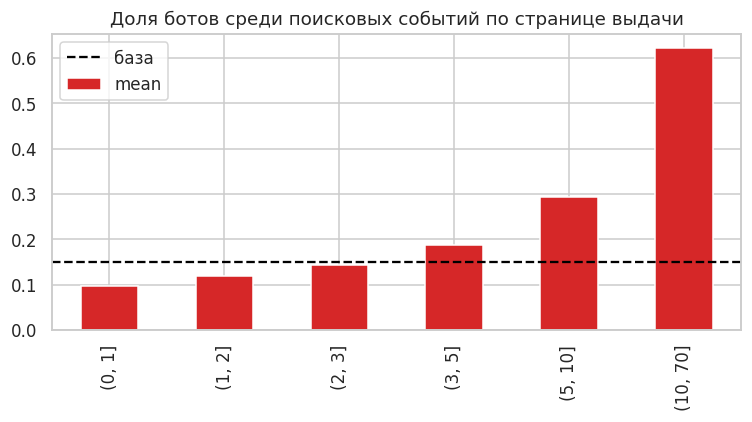

In [154]:
search = train_events[train_events.event_name == 'search_results_view']
print(search.groupby('target').search_page.describe().round(2))
print('страница >3:', (search.search_page > 3).groupby(search.target).mean().round(3).to_dict(), '| >10:', (search.search_page > 10).groupby(search.target).mean().round(3).to_dict())

by_page = search.groupby(pd.cut(search.search_page, [0, 1, 2, 3, 5, 10, 70]), observed=True).target.agg(['mean', 'size'])
baseline = search.target.mean()
print(by_page.round(3)); print('доля ботов среди всех поисковых событий (база):', round(baseline, 3))

queries = search.groupby('cookie_id').search_query.agg(['size', 'nunique']).join(y)
queries['repeat_share'] = 1 - queries['nunique'] / queries['size']
print('доля повторных запросов у куки:', queries.groupby('target').repeat_share.mean().round(3).to_dict())

ax = by_page['mean'].plot.bar(color=BOT, figsize=(7, 4))
ax.axhline(baseline, color='black', ls='--', label='база'); ax.legend()
ax.set_title('Доля ботов среди поисковых событий по странице выдачи'); ax.set_xlabel(''); show()

Боты листают выдачу заметно глубжеи чаще повторяют один и тот же запрос!!!

## анализ курсора

web-события без курсора: {0.0: 0.338, 1.0: 0.67}
web-куки БЕЗ единой точки курсора: {0: 0.288, 1: 0.573} | куки, у которых курсор есть всегда: {0: 0.376, 1: 0.172}

кук с >=2 точками курсора: 3922 | ботов: 250
        std_x  mean_x  mean_step
target                          
0       553.0   965.0      792.0
1       203.0   664.0      369.0
ROC-AUC std_x: 0.936
ROC-AUC mean_step: 0.932
ROC-AUC mean_x: 0.771
std_x < 300: ботов 196 из 250, людей 193 из 3672
std_x < 350: ботов 219 из 250, людей 265 из 3672
std_x < 400: ботов 231 из 250, людей 381 из 3672

люди: расстояние позиций курсора до равномерного по экрану 1920x1080 (0 = идеально равномерно): x 0.005 | y 0.005


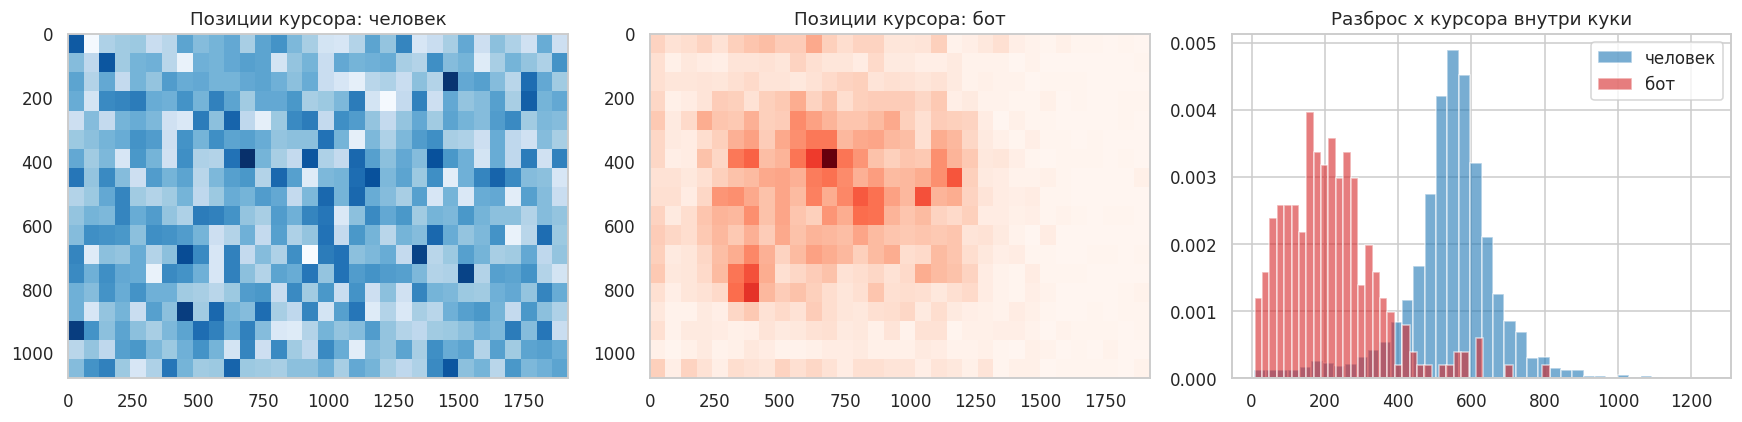

In [155]:
web = train_events[train_events.platform_clean == 'web'].copy()
web['no_pointer'] = web.pointer_x.isna()
web_cookie = web.groupby('cookie_id').no_pointer.agg(['sum', 'size']).join(y)
print('web-события без курсора:', web.groupby('target').no_pointer.mean().round(3).to_dict())
print('web-куки БЕЗ единой точки курсора:', (web_cookie['sum'] == web_cookie['size']).groupby(web_cookie.target).mean().round(3).to_dict(), '| куки, у которых курсор есть всегда:', (web_cookie['sum'] == 0).groupby(web_cookie.target).mean().round(3).to_dict())

points = web.dropna(subset=['pointer_x']).sort_values(['cookie_id', 'event_ts'])
points['step'] = np.hypot(points.groupby('cookie_id').pointer_x.diff(), points.groupby('cookie_id').pointer_y.diff())
cursor = points.groupby('cookie_id').agg(n_points=('pointer_x', 'size'), std_x=('pointer_x', 'std'), mean_x=('pointer_x', 'mean'), mean_step=('step', 'mean')).join(y)

cursor = cursor[cursor.n_points >= 2]
print('\nкук с >=2 точками курсора:', len(cursor), '| ботов:', int(cursor.target.sum()))
print(cursor.groupby('target')[['std_x', 'mean_x', 'mean_step']].median().round(0))
for col in ['std_x', 'mean_step', 'mean_x']:
    print(f'ROC-AUC {col}:', round(auc(cursor.target, cursor[col]), 3))
for limit in [300, 350, 400]:
    hit = cursor[cursor.std_x < limit]
    print(f'std_x < {limit}: ботов {int(hit.target.sum())} из {int(cursor.target.sum())}, людей {int((hit.target == 0).sum())} из {int((cursor.target == 0).sum())}')

humans = points[points.target == 0]
print('\nлюди: расстояние позиций курсора до равномерного по экрану 1920x1080 (0 = идеально равномерно): x',
      round(stats.kstest(humans.pointer_x / 1920, 'uniform').statistic, 3), '| y', round(stats.kstest(humans.pointer_y / 1080, 'uniform').statistic, 3))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, t in zip(ax[:2], (0, 1)):
    d = points[points.target == t]
    a.hist2d(d.pointer_x, d.pointer_y, bins=[32, 18], range=[[0, 1920], [0, 1080]], cmap='Reds' if t else 'Blues')
    a.invert_yaxis(); a.set_title(f'Позиции курсора: {NAME[t]}')
hist_by_class(ax[2], cursor, 'std_x', 40, 'Разброс x курсора внутри куки')
show()

Видно, что у людей реальное человеческое движение мыши, а у ботов же координаты сжаты в компактное пятно!

## анализ возраста куки

                mean  size
bucket                    
(0.0, 0.25]    0.187   252
(0.25, 1.0]    0.178  1044
(1.0, 3.0]     0.157  1080
(3.0, 7.0]     0.117   256
(7.0, 30.0]    0.050   939
(30.0, 90.0]   0.056  3846
(90.0, 500.0]  0.055  3674
моложе 3 дней: боты 0.448 | люди 0.194
старше 7 дней: боты 0.518 | люди 0.784
доля кук моложе 3 дней: train 0.214 | test 0.219


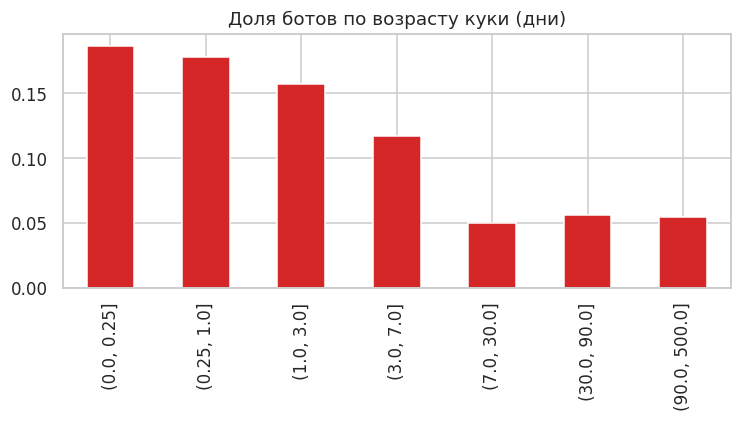

In [156]:
age = train.assign(age_days=(train.window_start_ts - train.cookie_created_at).dt.total_seconds() / 86400)
age['bucket'] = pd.cut(age.age_days, [0, 0.25, 1, 3, 7, 30, 90, 500])
by_age = age.groupby('bucket', observed=True).target.agg(['mean', 'size'])
print(by_age.round(3))

young = age.age_days < 3
print('моложе 3 дней: боты', young[age.target == 1].mean().round(3), '| люди', young[age.target == 0].mean().round(3))
print('старше 7 дней: боты', (age.age_days[age.target == 1] > 7).mean().round(3), '| люди', (age.age_days[age.target == 0] > 7).mean().round(3))
test_young = ((test.window_start_ts - test.cookie_created_at).dt.total_seconds() / 86400 < 3).mean()
print('доля кук моложе 3 дней: train', young.mean().round(3), '| test', round(test_young, 3))

ax = by_age['mean'].plot.bar(color=BOT, figsize=(7, 4)); ax.set_title('Доля ботов по возрасту куки (дни)'); ax.set_xlabel(''); show()

свежие куки (моложе 3 дней) заметно чаще боты

## общие объявления между куками

есть общее объявление с другой кукой: {0: 0.567, 1: 0.801}
         mean  size
others             
0       0.040  4516
1       0.088  5360
2       0.221   950
3       0.425    87
4       0.800     5


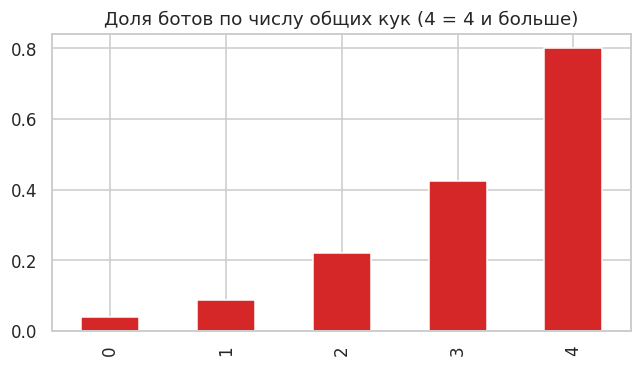

In [157]:
day = events.window_start_ts.dt.normalize().rename('day')          # «день» куки = дата начала её окна
pairs = events.assign(day=day).dropna(subset=['item_id']).drop_duplicates(['cookie_id', 'item_id', 'day'])
pairs['other_cookies'] = pairs.groupby(['day', 'item_id']).cookie_id.transform('nunique') - 1   # сколько ДРУГИХ кук смотрели то же объявление
shared = pairs.groupby('cookie_id').other_cookies.max().rename('max_others').to_frame().join(y, how='inner')
print('есть общее объявление с другой кукой:', (shared.max_others > 0).groupby(shared.target).mean().round(3).to_dict())

by_shared = shared.assign(others=shared.max_others.clip(upper=4)).groupby('others').target.agg(['mean', 'size'])
print(by_shared.round(3))
ax = by_shared['mean'].plot.bar(color=BOT, figsize=(6, 3.5)); ax.set_title('Доля ботов по числу общих кук (4 = 4 и больше)'); ax.set_xlabel(''); show()

## проверка отличаются ли train и test

In [158]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_predict, StratifiedKFold

all_cookie = events.groupby('cookie_id')
drift = pd.DataFrame({'n_events': all_cookie.size(), 'pause_median': all_cookie.pause.median(),
                      'web_share': all_cookie.platform_clean.apply(lambda s: (s == 'web').mean()),
                      'headless': all_cookie.is_headless.mean(), 'n_locations': all_cookie.item_location.nunique()}
                     ).join(cookies.set_index('cookie_id')[['split', 'cookie_created_at', 'window_start_ts']])
drift['age_days'] = (drift.window_start_ts - drift.cookie_created_at).dt.total_seconds() / 86400
drift_cols = ['n_events', 'pause_median', 'web_share', 'headless', 'n_locations', 'age_days']
print(drift.groupby('split')[drift_cols].mean().round(3).T)

# если по этим признакам можно отличить train от test, значит сдвиг есть
is_test = (drift.split == 'test').astype(int)
pred = cross_val_predict(lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, verbose=-1, random_state=42), drift[drift_cols], is_test,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42), method='predict_proba')[:, 1]
print('adversarial ROC-AUC (train против test):', round(roc_auc_score(is_test, pred), 3), '(0.5 = сдвига нет)')

split            test    train
n_events       17.997   17.625
pause_median  208.301  215.988
web_share       0.542    0.533
headless        0.028    0.026
n_locations     6.408    6.258
age_days       71.647   71.867
adversarial ROC-AUC (train против test): 0.49 (0.5 = сдвига нет)


# Генерация признаков

## вспомогательная функция

In [159]:
def entropy_by_cookie(df, col):
    counts = df.groupby(['cookie_id', col]).size()
    share = counts / counts.groupby('cookie_id').transform('sum')
    return -(share * np.log(share)).groupby('cookie_id').sum()

## паузы

In [160]:
def features_pauses(events):
    seconds = (events.event_ts - events.window_start_ts).dt.total_seconds()
    pause = seconds.groupby(events.cookie_id).diff()
    pauses = events[['cookie_id']].assign(pause=pause).dropna(subset=['pause'])
    by_cookie = pauses.groupby('cookie_id').pause
    within_session = pauses[pauses.pause <= 1800].groupby('cookie_id').pause.median()
    return pd.DataFrame({
        'pause_median': by_cookie.median(),
        'pause_p10': by_cookie.quantile(.1),
        'pause_p90': by_cookie.quantile(.9),
        'pause_share_3_15s': by_cookie.apply(lambda s: s.between(3, 15).mean()),
        'pause_unique_ratio': by_cookie.apply(lambda s: s.nunique() / len(s)),
        'pause_log_std': by_cookie.apply(lambda s: np.log1p(s).std()),
        'pause_in_session_median': within_session,
        'seconds_unique_ratio': events.event_ts.dt.second.groupby(events.cookie_id).apply(lambda s: s.nunique() / len(s)),
    })

## курсор

In [161]:
def features_cursor(events):
    web = events[events.platform_clean == 'web']
    no_pointer = web.pointer_x.isna().groupby(web.cookie_id)
    points = events[events.pointer_x.notna()]
    by_cookie = points.groupby('cookie_id')
    n_points = by_cookie.size()
    step = np.hypot(by_cookie.pointer_x.diff(), by_cookie.pointer_y.diff())
    step_by_cookie = step.groupby(points.cookie_id)
    at_edge = (points.pointer_x <= 0) | (points.pointer_y <= 0) | (points.pointer_x >= 1919) | (points.pointer_y >= 1080)

    basic = pd.DataFrame({
        'ptr_n_events': n_points,
        'ptr_std_x': by_cookie.pointer_x.std(), 'ptr_mean_x': by_cookie.pointer_x.mean(), 'ptr_mean_step': step_by_cookie.mean(),
        'web_no_pointer_count': no_pointer.sum(), 'web_no_pointer_share': no_pointer.mean(),
    })
    fingerprints = pd.DataFrame({
        'c_std_y': by_cookie.pointer_y.std(), 'c_mean_y': by_cookie.pointer_y.mean(),
        'c_radius': np.hypot(by_cookie.pointer_x.std(), by_cookie.pointer_y.std()),
        'c_step_std': step_by_cookie.std(),
        'c_round10_share': ((points.pointer_x % 10 == 0) & (points.pointer_y % 10 == 0)).groupby(points.cookie_id).mean(),
        'c_edge_share': at_edge.groupby(points.cookie_id).mean(),
        'c_x_eq_y_share': (points.pointer_x == points.pointer_y).groupby(points.cookie_id).mean(),
        'c_unique_ratio': points.groupby(['cookie_id', 'pointer_x', 'pointer_y']).size().groupby('cookie_id').size() / n_points,
    })
    fingerprints.loc[n_points[n_points < 2].index] = np.nan
    return basic.join(fingerprints)

## объём и разнообразие

In [162]:
def features_volume(events):
    by_cookie = events.groupby('cookie_id')
    n_categories = by_cookie.item_category.nunique()
    switched = by_cookie.item_category.shift().ne(events.item_category) & events.item_category.notna() & by_cookie.item_category.shift().notna()
    return pd.DataFrame({
        'n_events': by_cookie.size(),
        'n_locations': by_cookie.item_location.nunique(),
        'n_categories': n_categories,
        'events_per_category': by_cookie.size() / n_categories.replace(0, np.nan),
        'category_switch_rate': switched.groupby(events.cookie_id).mean(),
    })

def features_diversity(events):
    n_events = events.groupby('cookie_id').size()
    items = events[events.item_id.notna()]
    queries = events[events.search_query.notna()]
    pages = events[events.search_page.notna()]
    sellers = items.dropna(subset=['seller_type'])
    views = (events.event_name == 'item_view').groupby(events.cookie_id).sum()
    searches = (events.event_name == 'search_results_view').groupby(events.cookie_id).sum()

    f = pd.DataFrame(index=n_events.index)
    f['d_item_nunique'] = items.groupby('cookie_id').item_id.nunique()
    f['d_item_unique_ratio'] = f.d_item_nunique / items.groupby('cookie_id').size()
    f['d_items_per_event'] = f.d_item_nunique / n_events
    f['d_cat_entropy'] = entropy_by_cookie(items.dropna(subset=['item_category']), 'item_category')
    f['d_loc_entropy'] = entropy_by_cookie(items.dropna(subset=['item_location']), 'item_location')
    f['d_query_nunique'] = queries.groupby('cookie_id').search_query.nunique()
    f['d_query_unique_ratio'] = f.d_query_nunique / queries.groupby('cookie_id').size()
    f['d_query_len_mean'] = queries.search_query.str.len().groupby(queries.cookie_id).mean()
    f['d_query_words_mean'] = queries.search_query.str.split().str.len().groupby(queries.cookie_id).mean()
    f['d_page_gt3_share'] = (pages.search_page > 3).groupby(pages.cookie_id).mean()                   # доля глубоких страниц выдачи
    f['d_page_depth_per_query'] = pages.groupby(['cookie_id', 'search_query']).search_page.max().groupby('cookie_id').mean()
    seller_share = pd.crosstab(sellers.cookie_id, sellers.seller_type, normalize='index')
    seller_share.columns = ['d_seller_share_' + c for c in seller_share.columns]
    f = f.join(seller_share)
    f['d_item_view_per_search'] = views / searches.replace(0, np.nan)
    return f

## поиск и воронка

In [163]:
def features_search(events):
    search = events[events.event_name == 'search_results_view']
    by_cookie = search.groupby('cookie_id')
    return pd.DataFrame({
        'search_page_mean': by_cookie.search_page.mean(),
        'search_page_max': by_cookie.search_page.max(),
        'search_query_repeat': by_cookie.search_query.apply(lambda s: 1 - s.nunique() / len(s)),
    })

def features_funnel(events):
    count = lambda name: (events.event_name == name).groupby(events.cookie_id).sum()
    views = count('item_view') + 1
    contacts = count('contact_phone_show') + count('contact_chat_open') + count('contact_message_sent')
    return pd.DataFrame({'contacts_per_view': contacts / views, 'favorites_per_view': count('favorite_add') / views, 'swipes_per_view': count('photo_swipe') / views})

## user-agent

In [164]:
def features_ua(events):
    ua = events.user_agent.fillna('')
    by_cookie = events.groupby('cookie_id')
    n_events = by_cookie.size()

    mobile_ua = ua.str.contains('Android|iPhone|iPad')
    mobile_platform = events.platform_clean.isin(['android', 'ios'])
    os_conflict = (((events.platform_clean == 'android') & ua.str.contains('iPhone|iPad|Macintosh|Windows')) |
                   ((events.platform_clean == 'ios') & ua.str.contains('Android|Windows')))
    previous_ua = ua.groupby(events.cookie_id).shift()
    ua_changed = (ua != previous_ua) & previous_ua.notna()
    browser_version = pd.to_numeric(ua.str.extract(r'(?:Chrome|Firefox)/(\d+)')[0])
    family = np.where(ua.str.contains('Firefox'), 'firefox', 'chrome')
    version_lag = browser_version.groupby(family).transform('max') - browser_version
    headless = ua.str.contains('Headless')

    return pd.DataFrame({
        'u_mismatch_share': (mobile_ua != mobile_platform).groupby(events.cookie_id).mean(),
        'u_os_mismatch_share': os_conflict.groupby(events.cookie_id).mean(),
        'u_ua_nunique': by_cookie.user_agent.nunique(),
        'u_plat_nunique': by_cookie.platform_clean.nunique(),
        'u_ua_change_share': ua_changed.groupby(events.cookie_id).sum() / (n_events - 1).clip(lower=1),
        'u_major_lag_max': version_lag.groupby(events.cookie_id).max(),
        'u_major_min': browser_version.groupby(events.cookie_id).min(),
        'u_headless_share': headless.groupby(events.cookie_id).mean(),
        'is_headless_any': headless.groupby(events.cookie_id).max().astype(int),
        'u_scraper_share': ua.str.contains('curl|Go-http|Scrapy|urllib|node-fetch|python-requests').groupby(events.cookie_id).mean(),
    })

## кука и связи между куками

In [165]:
def features_context(events, meta):
    m = meta.set_index('cookie_id')
    return pd.DataFrame({
        'age_days': (m.window_start_ts - m.cookie_created_at).dt.total_seconds() / 86400,
        'night_share': (events.event_ts.dt.hour < 6).groupby(events.cookie_id).mean(),
    })

def features_shared_items(events):
    day = events.window_start_ts.dt.normalize().rename('day')
    pairs = events.assign(day=day).dropna(subset=['item_id']).drop_duplicates(['cookie_id', 'item_id', 'day'])
    pairs['other_cookies'] = pairs.groupby(['day', 'item_id']).cookie_id.transform('nunique') - 1
    return pairs.groupby('cookie_id').other_cookies.max().rename('shared_items_max').to_frame()

## сборка таблицы признаков

In [166]:
def build_features(events, meta):
    groups = {
        'паузы': features_pauses(events),
        'курсор': features_cursor(events),
        'объём': features_volume(events),
        'разнообразие': features_diversity(events),
        'поиск': features_search(events),
        'воронка': features_funnel(events),
        'UA': features_ua(events),
        'кука': pd.concat([features_context(events, meta), features_shared_items(events)], axis=1),
    }
    table = pd.concat(groups.values(), axis=1).reindex(meta.cookie_id)
    table = table.replace([np.inf, -np.inf], np.nan)
    table['n_events'] = table['n_events'].fillna(0)
    return table, {name: list(df.columns) for name, df in groups.items()}

features, FEATURE_GROUPS = build_features(events, cookies)
FEATURES = sum(FEATURE_GROUPS.values(), [])
X_train = features.loc[train.cookie_id]
X_test = features.loc[test.cookie_id]
y_train = train.set_index('cookie_id').target.loc[X_train.index]

print('признаков:', len(FEATURES), '| X_train', X_train.shape, '| X_test', X_test.shape)
print({name: len(cols) for name, cols in FEATURE_GROUPS.items()})

признаков: 60 | X_train (11091, 60) | X_test (4909, 60)
{'паузы': 8, 'курсор': 14, 'объём': 5, 'разнообразие': 14, 'поиск': 3, 'воронка': 3, 'UA': 10, 'кука': 3}


## проверка

In [167]:
assert len(FEATURES) == 60 and len(set(FEATURES)) == 60
assert X_train.index.is_unique and X_test.index.is_unique
assert not np.isinf(features.values.astype(float)).any()
print('кук без событий в окне: train', int((X_train.n_events == 0).sum()), '| test', int((X_test.n_events == 0).sum()))

control = ['ptr_std_x', 'c_radius', 'pause_median', 'd_page_depth_per_query', 'events_per_category', 'n_locations']
print('\nROC-AUC ключевых признаков:')
for col in control:
    print(f'  {col:24s} {auc(y_train, X_train[col]):.3f}')

coverage = pd.DataFrame({'train': X_train.notna().mean(), 'test': X_test.notna().mean()})
print('\nпризнаки, у которых заполненность train и test отличается больше чем на 2 п.п.:')
gap = coverage[(coverage.train - coverage.test).abs() > 0.02]
print(gap.round(3).to_string() if len(gap) else '  нет')

if 'cand' in globals() and 'V2' in globals():
    old = pd.concat([cand[[c for c in FEATURES if c in cand.columns]], V2[[c for c in FEATURES if c in V2.columns]]], axis=1).astype(float)
    fresh = X_train.loc[old.index, old.columns].astype(float)
    report = pd.DataFrame({'разный пропуск': (old.isna() != fresh.isna()).sum(), 'разное значение': ((old - fresh).abs() > 1e-6).sum()})
    report = report[(report > 0).any(axis=1)]
    print('\nсверка с прежними признаками:', report.to_string() if len(report) else 'все совпали')

кук без событий в окне: train 0 | test 0

ROC-AUC ключевых признаков:
  ptr_std_x                0.936
  c_radius                 0.939
  pause_median             0.727
  d_page_depth_per_query   0.727
  events_per_category      0.721
  n_locations              0.711

признаки, у которых заполненность train и test отличается больше чем на 2 п.п.:
  нет

сверка с прежними признаками: все совпали


# отбор признаков

In [168]:
y_int = y_train.values.astype(int)

def make_time_folds(meta, cookie_index, cutoffs=(4, 6, 8, 10, 12)):
    day = meta.set_index('cookie_id').window_start_ts.dt.normalize().reindex(cookie_index)
    days = sorted(day.unique())
    folds = []
    for k in cutoffs:
        train_mask = (day < days[k]).values
        valid_mask = ((day >= days[k]) & (day <= days[min(k + 1, len(days) - 1)])).values
        folds.append((train_mask, valid_mask))
    return folds

FOLDS = make_time_folds(train, X_train.index)
IS_VALID = np.any([valid for _, valid in FOLDS], axis=0)
y_valid = y_int[IS_VALID]
segment = np.where(X_train.ptr_std_x.notna(), 'A', np.where(X_train.web_no_pointer_count.notna(), 'B', 'C'))
segment_valid = segment[IS_VALID]
print(f'проверка: {len(y_valid)} кук, ботов {y_valid.sum()} ({y_valid.mean():.1%}) | сегменты:', dict(zip(*np.unique(segment_valid, return_counts=True))))

def make_model(seed):
    return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.6, reg_lambda=5, verbose=-1, random_state=seed)

def predict_out_of_time(columns, seeds=[42]):
    pred = np.full(len(X_train), np.nan)
    for train_mask, valid_mask in FOLDS:
        fold_preds = [make_model(s).fit(X_train.loc[train_mask, columns], y_int[train_mask]).predict_proba(X_train.loc[valid_mask, columns])[:, 1] for s in seeds]
        pred[valid_mask] = np.mean(fold_preds, axis=0)
    return pred[IS_VALID]

def score_report(pred):
    mobile = segment_valid == 'C'
    row = {'PR-AUC': average_precision_score(y_valid, pred), 'ROC': roc_auc_score(y_valid, pred), 'P@R': precision_at_recall(y_valid, pred),
           'PR-AUC C': average_precision_score(y_valid[mobile], pred[mobile])}
    for name in 'ABC':
        m = segment_valid == name
        row[f'P@R {name}'] = precision_at_recall(y_valid[m], pred[m])
    return row

def bootstrap_diff(metric, pred_a, pred_b, mask=None, n=100, seed=0):
    idx = np.arange(len(y_valid)) if mask is None else np.where(mask)[0]
    rng, diffs = np.random.default_rng(seed), []
    for _ in range(n):
        i = rng.choice(idx, len(idx))
        diffs.append(metric(y_valid[i], pred_b[i]) - metric(y_valid[i], pred_a[i]))
    return np.mean(diffs), np.std(diffs)

проверка: 7786 кук, ботов 636 (8.2%) | сегменты: {np.str_('A'): np.int64(2738), np.str_('B'): np.int64(1362), np.str_('C'): np.int64(3686)}


In [169]:
full_pred = predict_out_of_time(FEATURES)
mobile_valid = segment_valid == 'C'
results = {'полный набор 60': score_report(full_pred)}

for group, cols in FEATURE_GROUPS.items():
    kept = [c for c in FEATURES if c not in cols]
    pred = predict_out_of_time(kept)
    row = score_report(pred)
    row['погрешность PR-AUC'], row['шум'] = bootstrap_diff(average_precision_score, full_pred, pred)
    row['погрешность PR-AUC C'], row['шум C'] = bootstrap_diff(average_precision_score, full_pred, pred, mask=mobile_valid)
    results[f'без: {group} ({len(cols)})'] = row
    print('готово: без', group, flush=True)

table = pd.DataFrame(results).T
delta, noise, delta_c, noise_c = table['погрешность PR-AUC'], table['шум'], table['погрешность PR-AUC C'], table['шум C']
table['вывод'] = np.select([(delta < -2 * noise) | (delta_c < -2 * noise_c), (delta > 2 * noise) | (delta_c > 2 * noise_c)], ['нужна', 'мешает'], default='не доказана')
table.loc['полный набор 60', 'вывод'] = ''
print(table[['PR-AUC', 'PR-AUC C', 'ROC', 'P@R', 'P@R A', 'P@R B', 'P@R C', 'погрешность PR-AUC', 'шум', 'погрешность PR-AUC C', 'шум C', 'вывод']].round(3).to_string())

готово: без паузы
готово: без курсор
готово: без объём
готово: без разнообразие
готово: без поиск
готово: без воронка
готово: без UA
готово: без кука
                        PR-AUC  PR-AUC C    ROC    P@R  P@R A  P@R B  P@R C  погрешность PR-AUC    шум  погрешность PR-AUC C  шум C        вывод
полный набор 60          0.781     0.582  0.937  0.757  0.846  0.884  0.292                 NaN    NaN                   NaN    NaN             
без: паузы (8)           0.711     0.499  0.922  0.596  0.829  0.676  0.197              -0.071  0.009                -0.081  0.020        нужна
без: курсор (14)         0.706     0.581  0.901  0.519  0.342  0.889  0.281              -0.074  0.009                -0.001  0.006        нужна
без: объём (5)           0.777     0.568  0.937  0.750  0.836  0.874  0.231              -0.004  0.002                -0.014  0.006        нужна
без: разнообразие (14)   0.774     0.561  0.934  0.724  0.829  0.878  0.261              -0.008  0.004                -0.021 

In [171]:
DROP_GROUPS = []
candidates = [c for g, cols in FEATURE_GROUPS.items() if g not in DROP_GROUPS for c in cols]
group_of = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}

def feature_importance(columns, seeds=SEEDS):
    total, n = pd.Series(0.0, index=columns), 0
    for train_mask, _ in FOLDS:
        for s in seeds:
            model = make_model(s).set_params(importance_type='gain').fit(X_train.loc[train_mask, columns], y_int[train_mask])
            imp = pd.Series(model.feature_importances_, index=columns)
            total += imp / imp.sum(); n += 1
    return (total / n).sort_values(ascending=False)

importance = feature_importance(candidates)
ranking = pd.DataFrame({'доля важности, %': (importance * 100).round(2), 'группа': importance.index.map(group_of)})
print('самые важные 15:'); print(ranking.head(15).to_string())
print('\nсамые слабые 15:'); print(ranking.tail(15).to_string())

sizes = [n for n in (20, 30, 40, 50) if n < len(candidates)] + [len(candidates)]
preds_top = {n: predict_out_of_time(list(importance.index[:n])) for n in sizes}
reference = preds_top[sizes[-1]]
rows = {}
for n, pred in preds_top.items():
    row = score_report(pred)
    row['погрешность PR-AUC'], row['шум'] = bootstrap_diff(average_precision_score, reference, pred)
    row['погрешность PR-AUC C'], row['шум C'] = bootstrap_diff(average_precision_score, reference, pred, mask=mobile_valid)
    rows[n] = row
    print('готово: топ', n, flush=True)
top_table = pd.DataFrame(rows).T; top_table.index.name = 'признаков'
print(top_table[['PR-AUC', 'PR-AUC C', 'ROC', 'P@R', 'P@R C', 'погрешность PR-AUC', 'шум', 'погрешность PR-AUC C', 'шум C']].round(3).to_string())

ok = top_table[(top_table['погрешность PR-AUC'] >= -top_table['шум']) & (top_table['погрешность PR-AUC C'] >= -top_table['шум C'])]
N_FEATURES = int(ok.index.min())
SELECTED = list(importance.index[:N_FEATURES])
print(f'\nвыбрано признаков: {N_FEATURES} из {len(candidates)}')
print(pd.Series({g: len(set(cols) & set(SELECTED)) for g, cols in FEATURE_GROUPS.items()}).rename('признаков в наборе').to_string())

X_train_sel, X_test_sel = X_train[SELECTED], X_test[SELECTED]
pd.Series(SELECTED, name='feature').to_csv('selected_features.csv', index=False)

самые важные 15:
                         доля важности, %        группа
pause_median                        10.02         паузы
pause_in_session_median              8.23         паузы
c_radius                             6.08        курсор
ptr_std_x                            5.64        курсор
pause_unique_ratio                   4.67         паузы
c_edge_share                         4.14        курсор
d_page_depth_per_query               4.03  разнообразие
events_per_category                  4.00         объём
pause_share_3_15s                    3.46         паузы
pause_p90                            3.09         паузы
d_cat_entropy                        2.77  разнообразие
pause_log_std                        2.70         паузы
n_locations                          2.70         объём
n_categories                         2.44         объём
pause_p10                            2.25         паузы

самые слабые 15:
                     доля важности, %  группа
search_query_repeat    

# Обучение модели

In [176]:
FINAL_FEATURES = FEATURES

FACTORIES = {
    'LightGBM': lambda s: lgb.LGBMClassifier(n_estimators=300, force_row_wise=True, verbose=-1, random_state=s),
    'CatBoost': lambda s: CatBoostClassifier(iterations=300, random_seed=s, verbose=0, thread_count=-1),
    'HistGB':   lambda s: HistGradientBoostingClassifier(max_iter=300, random_state=s),
}
if XGBClassifier is not None:
    FACTORIES['XGBoost'] = lambda s: XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.6, reg_lambda=5,
                                                   eval_metric='logloss', tree_method='hist', n_jobs=-1, random_state=s)

def out_of_time(factory, seeds=SEEDS):
    pred = np.full(len(X_train), np.nan)
    for train_mask, valid_mask in FOLDS:
        fold_preds = [factory(s).fit(X_train.loc[train_mask, FINAL_FEATURES], y_int[train_mask]).predict_proba(X_train.loc[valid_mask, FINAL_FEATURES])[:, 1] for s in seeds]
        pred[valid_mask] = np.mean(fold_preds, axis=0)
    return pred[IS_VALID]

fold_of = np.full(len(X_train), -1)
for k, (_, valid_mask) in enumerate(FOLDS): fold_of[valid_mask] = k
fold_valid = fold_of[IS_VALID]
def rank_within_folds(pred):
    out = np.zeros(len(pred))
    for k in range(len(FOLDS)):
        m = fold_valid == k; out[m] = pd.Series(pred[m]).rank(pct=True).values
    return out

ranks = {}
for name, factory in FACTORIES.items():
    t0 = time.time(); ranks[name] = rank_within_folds(out_of_time(factory)); print(f'готово: {name} ({time.time() - t0:.0f} с)', flush=True)
single = list(ranks)
ENSEMBLES = {'ансамбль: Cat + XGB + LGB': [n for n in ('CatBoost', 'XGBoost', 'LightGBM') if n in ranks], f'ансамбль: все {len(single)}': single}
for label, members in ENSEMBLES.items():
    ranks[label] = np.mean([ranks[m] for m in members], axis=0)

mobile_valid = segment_valid == 'C'
reference = ranks['LightGBM']
table = pd.DataFrame({name: score_report(r) for name, r in ranks.items()}).T
d_all = {n: bootstrap_diff(average_precision_score, reference, r) for n, r in ranks.items()}
d_mob = {n: bootstrap_diff(average_precision_score, reference, r, mask=mobile_valid) for n, r in ranks.items()}
d_par = {n: bootstrap_diff(precision_at_recall, reference, r) for n, r in ranks.items()}
table['погрешность PR-AUC'], table['шум'] = [d_all[n][0] for n in table.index], [d_all[n][1] for n in table.index]
table['погрешность PR-AUC C'], table['шум C'] = [d_mob[n][0] for n in table.index], [d_mob[n][1] for n in table.index]
table['Δ P@R'], table['шум P@R'] = [d_par[n][0] for n in table.index], [d_par[n][1] for n in table.index]
print(table[['PR-AUC', 'PR-AUC C', 'ROC', 'P@R', 'P@R A', 'P@R B', 'P@R C', 'погрешность PR-AUC', 'шум', 'погрешность PR-AUC C', 'шум C', 'Δ P@R', 'шум P@R']].round(3).to_string())

FINAL_MODELS = [n for n in ('CatBoost', 'XGBoost', 'LightGBM') if n in FACTORIES]
print('\nв финал идут:', FINAL_MODELS)

готово: LightGBM (24 с)
готово: CatBoost (42 с)
готово: HistGB (43 с)
готово: XGBoost (14 с)
                           PR-AUC  PR-AUC C    ROC    P@R  P@R A  P@R B  P@R C  погрешность PR-AUC    шум  погрешность PR-AUC C  шум C  Δ P@R  шум P@R
LightGBM                    0.774     0.558  0.934  0.755  0.826  0.883  0.230               0.000  0.000                 0.000  0.000  0.000    0.000
CatBoost                    0.787     0.580  0.939  0.766  0.832  0.896  0.294               0.013  0.004                 0.023  0.010  0.022    0.023
HistGB                      0.775     0.562  0.934  0.732  0.832  0.888  0.249               0.000  0.003                 0.005  0.007 -0.011    0.022
XGBoost                     0.783     0.578  0.939  0.759  0.833  0.896  0.273               0.008  0.005                 0.022  0.009  0.005    0.025
ансамбль: Cat + XGB + LGB   0.789     0.583  0.940  0.777  0.838  0.896  0.262               0.015  0.003                 0.026  0.006  0.032    0.018
а

In [177]:
is_holdout = train.set_index('cookie_id').window_start_ts.reindex(X_train.index).ge('2026-04-17').values
y_hold = y_int[is_holdout]

def holdout_predict(factory, seeds=SEEDS):
    return np.mean([factory(s).fit(X_train.loc[~is_holdout, FINAL_FEATURES], y_int[~is_holdout]).predict_proba(X_train.loc[is_holdout, FINAL_FEATURES])[:, 1] for s in seeds], axis=0)

hold_preds = {name: holdout_predict(FACTORIES[name]) for name in FINAL_MODELS}
hold_ensemble = np.mean([pd.Series(p).rank(pct=True).values for p in hold_preds.values()], axis=0)

base_cols = ['n_events', 'd_item_nunique']
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0).fit(X_train.loc[~is_holdout, base_cols].fillna(0), y_int[~is_holdout])
candidates = {'бейзлайн организаторов (2 признака)': rf.predict_proba(X_train.loc[is_holdout, base_cols].fillna(0))[:, 1],
              **{f'одна модель: {n}': p for n, p in hold_preds.items()}, 'НАШ АНСАМБЛЬ': hold_ensemble}
hold_table = pd.DataFrame({n: {'PR-AUC': average_precision_score(y_hold, p), 'ROC': roc_auc_score(y_hold, p), 'P@R': precision_at_recall(y_hold, p)}
                           for n, p in candidates.items()}).T
print(f'кук {len(y_hold)}, ботов {y_hold.sum()}, константа {y_hold.mean():.3f}')
print(hold_table.round(3).to_string())

кук 1951, ботов 160, константа 0.082
                                     PR-AUC    ROC    P@R
бейзлайн организаторов (2 признака)   0.163  0.572  0.096
одна модель: CatBoost                 0.795  0.936  0.830
одна модель: XGBoost                  0.789  0.940  0.843
одна модель: LightGBM                 0.785  0.933  0.767
НАШ АНСАМБЛЬ                          0.795  0.939  0.818


In [179]:
def fit_predict_test(factory, seeds=SEEDS):
    return np.mean([factory(s).fit(X_train[FINAL_FEATURES], y_int).predict_proba(X_test[FINAL_FEATURES])[:, 1] for s in seeds], axis=0)

test_preds = {}
for name in FINAL_MODELS:
    t0 = time.time(); test_preds[name] = fit_predict_test(FACTORIES[name]); print(f'готово: {name} ({time.time() - t0:.0f} с)', flush=True)

test_score = np.mean([pd.Series(p).rank(pct=True).values for p in test_preds.values()], axis=0)

sample = pd.read_csv('/kaggle/input/datasets/sashatx/avito-test-task-sample/sample_submission.csv')
submission = sample[['cookie_id']].merge(pd.DataFrame({'cookie_id': X_test.index, 'score': test_score}), on='cookie_id', how='left')

assert list(sample.columns) == ['cookie_id', 'score'], list(sample.columns)
assert len(submission) == len(test) == len(sample) and submission.cookie_id.is_unique
assert set(submission.cookie_id) == set(test.cookie_id)
assert submission.score.notna().all() and submission.score.between(0, 1).all()
print('уникальных значений score:', submission.score.nunique(), 'из', len(submission))
print('корреляция моделей на test (Spearman):'); print(pd.DataFrame(test_preds).corr(method='spearman').round(3).to_string())
print('средняя вероятность бота по моделям (доля ботов в train', round(y_int.mean(), 3), '):', {n: round(p.mean(), 3) for n, p in test_preds.items()})

submission.to_csv('submission3.csv', index=False)
print('контрольная сумма score:', round(submission.score.sum(), 6))
print(submission.head())

готово: CatBoost (9 с)
готово: XGBoost (3 с)
готово: LightGBM (5 с)
уникальных значений score: 4372 из 4909
корреляция моделей на test (Spearman):
          CatBoost  XGBoost  LightGBM
CatBoost     1.000    0.955     0.900
XGBoost      0.955    1.000     0.903
LightGBM     0.900    0.903     1.000
средняя вероятность бота по моделям (доля ботов в train 0.081 ): {'CatBoost': np.float64(0.081), 'XGBoost': np.float32(0.084), 'LightGBM': np.float64(0.067)}
контрольная сумма score: 2455.0
             cookie_id     score
0  ck_99a4e5ef02d89493  0.754397
1  ck_54d463f7fd89ec3d  0.693963
2  ck_0fbbc7a6af300368  0.246214
3  ck_8fd4937eadd64fb6  0.347253
4  ck_dbb4bd4eda97255d  0.386094
